# **Seminární práce II.**
Johana Pribanová

### **1) Klasifikace zvukových záznamů**

In [1]:
from wfdb import rdsamp, rdrecord, rdann, plot_wfdb, dl_database, rdann, get_record_list, rdsamp
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from google.colab import drive
import os
import re
import scipy.fftpack as fft
import scipy.signal as sc
from scipy.stats import linregress

drive.mount("/content/drive")

Mounted at /content/drive


In [2]:
dir = "/content/drive/MyDrive/voiced_db"
record_names = get_record_list("voiced")

records = []
anotace = {}

for name in record_names:
  path = os.path.join(dir, name)
  r = rdrecord(path)

  records.append(r)

  c = r.comments[0]
  d_start = c.index("<diagnoses>")
  m_start = c.index("<medications>")
  diagnoza = c[d_start: m_start].replace("<diagnoses>: ", "").strip()

  anotace[name] = [diagnoza, 1 if diagnoza == "healthy" else 0]

In [11]:
df = pd.DataFrame.from_dict(anotace, orient="index", columns=["diagnoza", "healthy"])
df

,diagnoza,healthy
voice001,hyperkinetic dysphonia,0
voice002,healthy,1
voice003,hyperkinetic dysphonia,0
voice004,hypokinetic dysphonia,0
voice005,hypokinetic dysphonia,0
...,...,...
voice204,healthy,1
voice205,hyperkinetic dysphonia,0
voice206,healthy,1
voice207,healthy,1


In [3]:
def analyze(s, plot):
  fs = s.fs
  signal = s.p_signal[:, 0]

  is_flat = np.diff(signal) == 0
  flat_indices = np.where(is_flat)[0]
  signal[flat_indices] = np.nan

  series = pd.Series(signal).interpolate(method="linear")
  signal = series.dropna().to_numpy()
  times = np.arange(signal.shape[0]) / fs

  n = len(signal)
  okno = np.hamming(n)
  fourier = fft.fft(signal * okno)
  amplitudy = np.abs(fourier)
  frekvence = np.linspace(0, fs, len(amplitudy))

  log = np.log(amplitudy)
  kepstr = fft.ifft(log).real
  start = 20
  end = 135
  relevantni_kepstr = kepstr[start:end]
  quefrency = np.arange(len(relevantni_kepstr)) / fs

  maximum = np.max(relevantni_kepstr)
  avg_val = np.mean(relevantni_kepstr)

  fig, ax = plt.subplots(figsize=(10, 4))
  px, freqs, bins, im = ax.specgram(signal, NFFT=512, Fs=fs, noverlap=400, cmap="inferno", scale="dB")
  plt.close(fig)

  max_indices = np.argmax(px, axis=0)
  dominantni_freq = freqs[max_indices]
  instability = np.std(dominantni_freq)

  hlasitost = np.sum(px)

  if (plot):
    plt.figure(figsize=[17, 5])
    plt.xlabel("time (s)")
    plt.ylabel("amplituda")
    plt.title(f"zvukovy zaznam {s.record_name}")
    plt.plot(times, signal)
    plt.figure(figsize=[17, 5])
    plt.xlabel("frekvence (Hz)")
    plt.ylabel("amplituda")
    plt.title(f"fourierova transformace signalu {s.record_name}")
    plt.plot(frekvence, fourier, color="green")
    plt.figure(figsize=[17, 5])
    plt.xlabel("quefrence (1/Hz)")
    plt.ylabel("amplituda")
    plt.title(f"kepstralni signal {s.record_name}: peak hodnota {round(maximum, 2)}")
    plt.plot(quefrency, relevantni_kepstr, color="red")
    plt.xlim(0, 0.015)
    plt.ylim(-0.1, 1)
    plt.figure(figsize=[10, 4])
    plt.xlabel("time")
    plt.ylabel("frekvence")
    plt.title(f"spectogram signalu {s.record_name}")
    p, f, b, i = plt.specgram(signal, NFFT=512, Fs=fs, noverlap=400, cmap="inferno", scale="dB")
    bar = plt.colorbar(i)
    bar.set_label("intenzita (dB)")

  return round(maximum, 2), round(instability, 2), round(hlasitost, 2),

vypocty = {}
for r in records:
  maximum, instability, hlasitost = analyze(r, False)
  anotace_val = anotace[r.record_name][0]

  if (maximum >= 0.4):
    vypocty[r.record_name] = ["healthy", 1, anotace_val, maximum, instability, hlasitost, 1 if anotace_val == "healthy" else 0]
  elif (maximum >= 0.2 and instability >= 70):
    vypocty[r.record_name] = ["hyperkinetic dysphonia", 0, anotace_val, maximum, instability, hlasitost, 1 if anotace_val == "hyperkinetic dysphonia" else 0]
  elif (maximum > 0.13 and hlasitost > 0.2):
    vypocty[r.record_name] = ["reflux laryngitis", 0, anotace_val, maximum, instability, hlasitost, 1 if anotace_val == "reflux laryngitis" else 0]
  else:
    vypocty[r.record_name] = ["hypokinetic dysphonia", 0, anotace_val, maximum, instability, hlasitost, 1 if anotace_val == "hypokinetic dysphonia" else 0]

df2 = pd.DataFrame.from_dict(vypocty, orient="index", columns=["diagnoza", "healthy", "anotace", "cpp", "instability", "hlasitost" ,"match"])

(0.55, 156.41, 1.83)

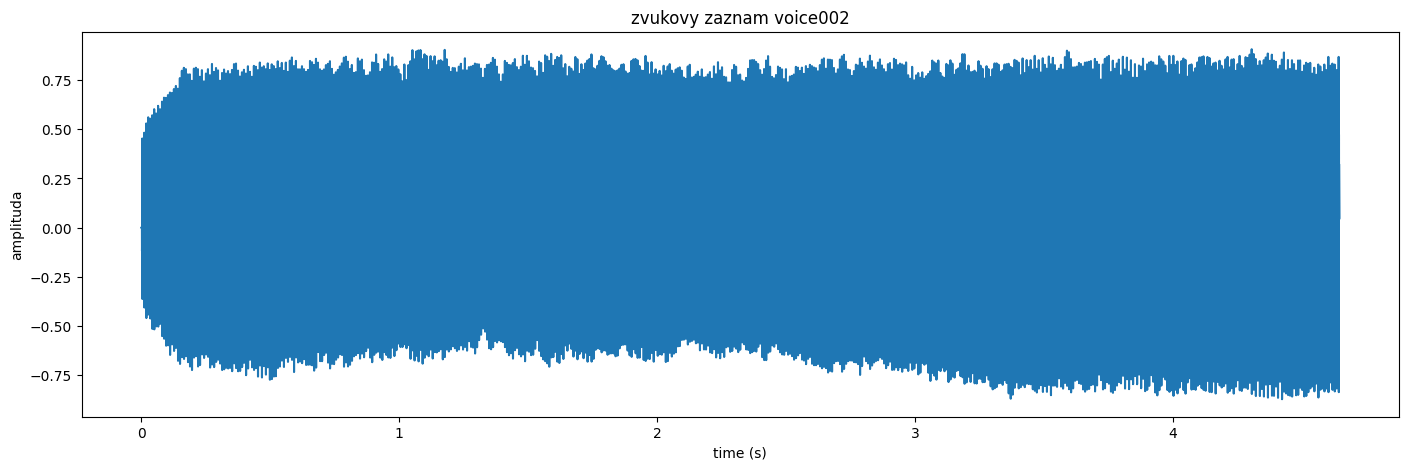

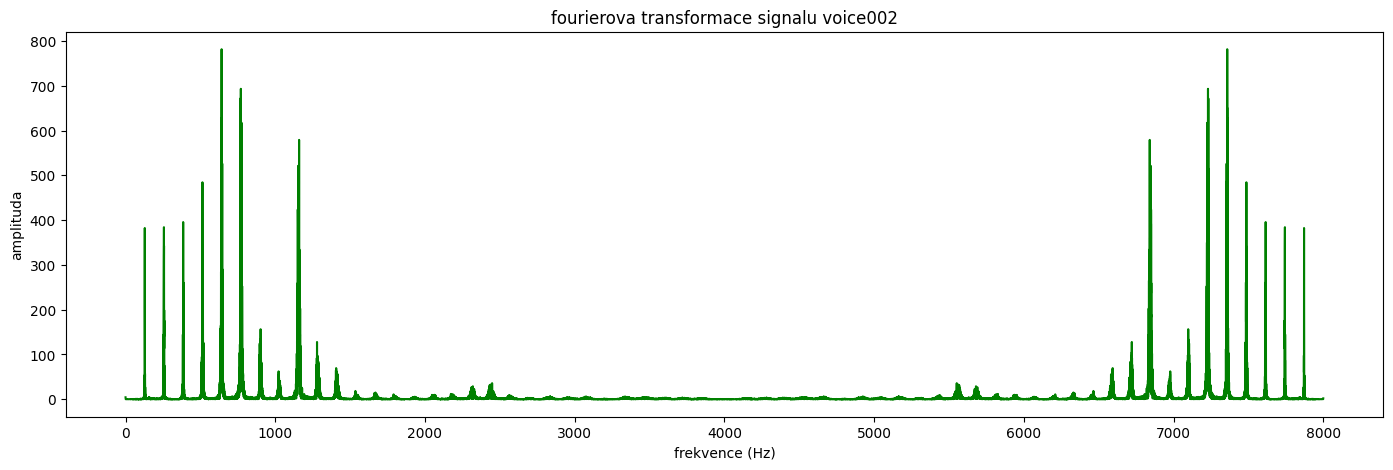

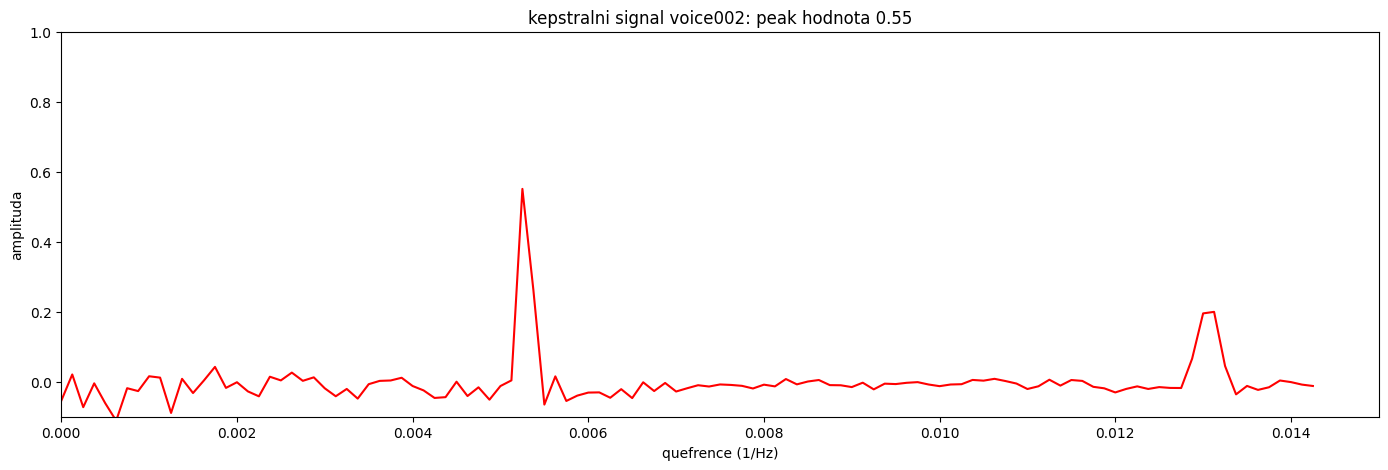

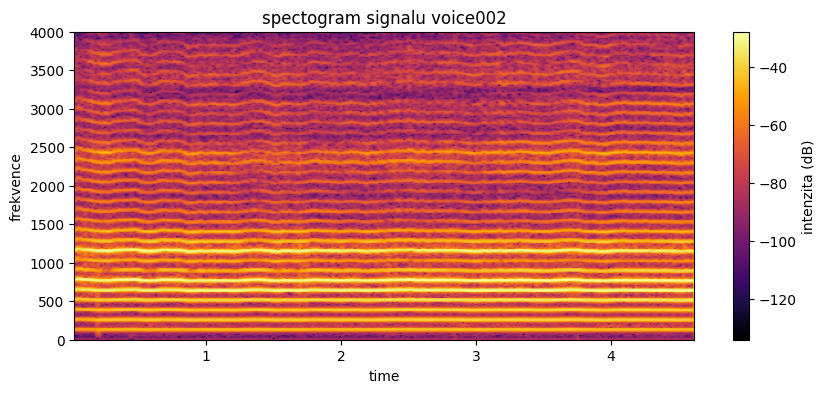

In [4]:
analyze(records[1], True)

(0.18, 78.3, 0.91)

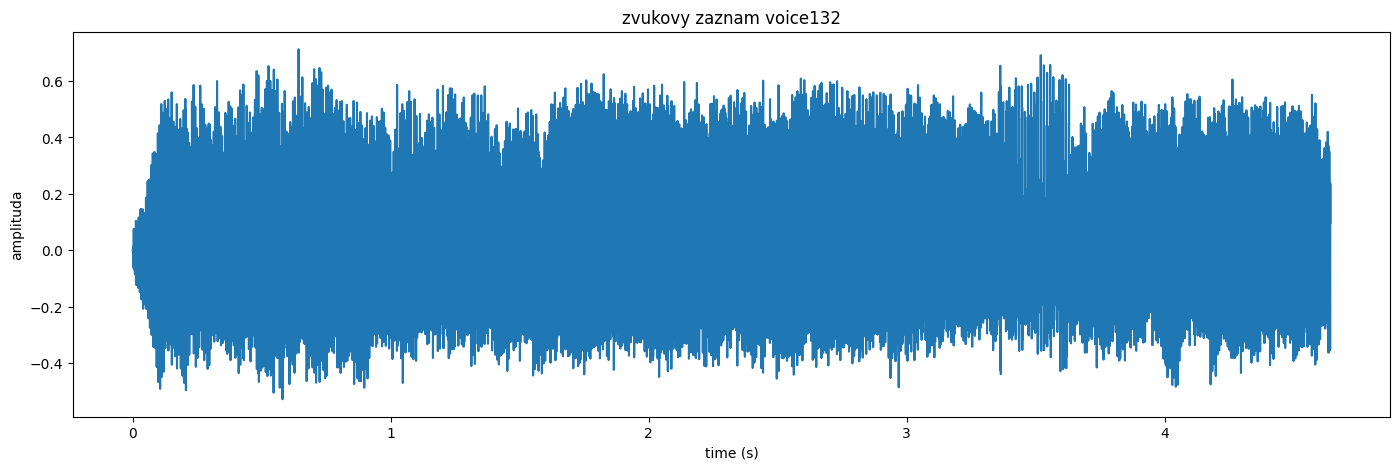

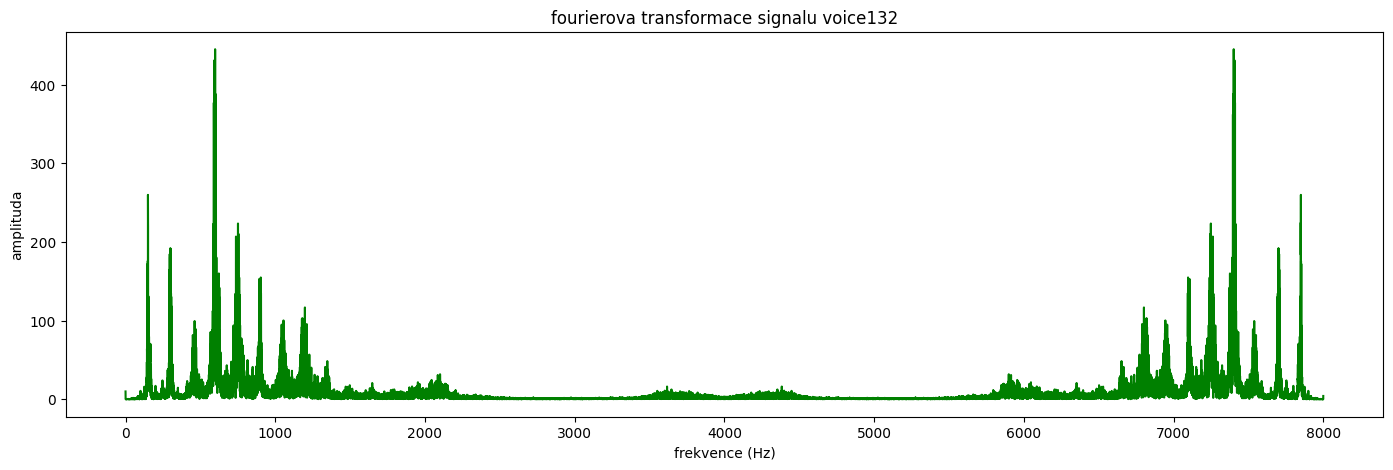

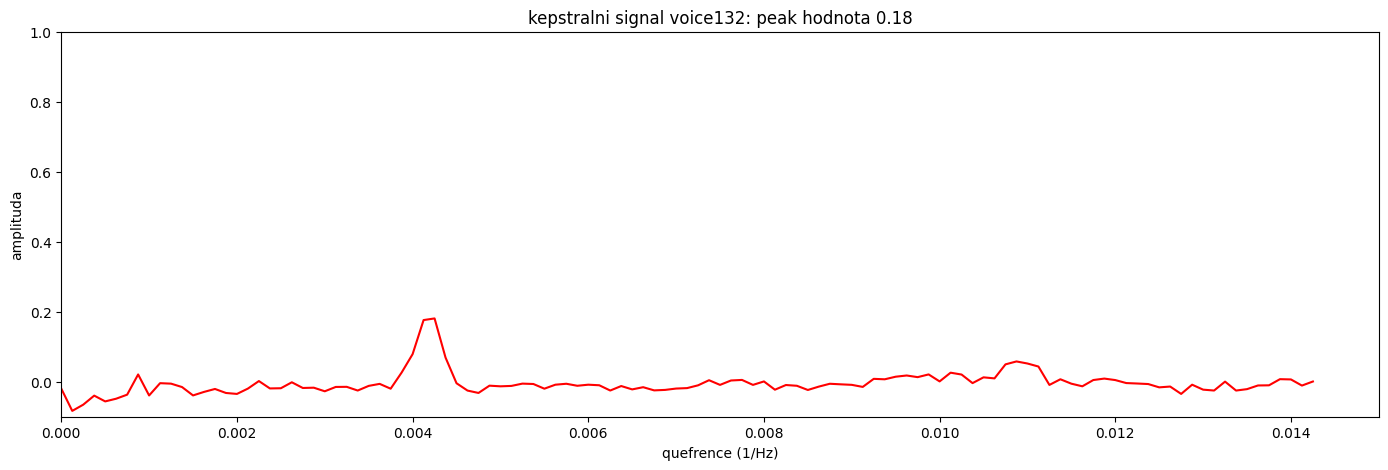

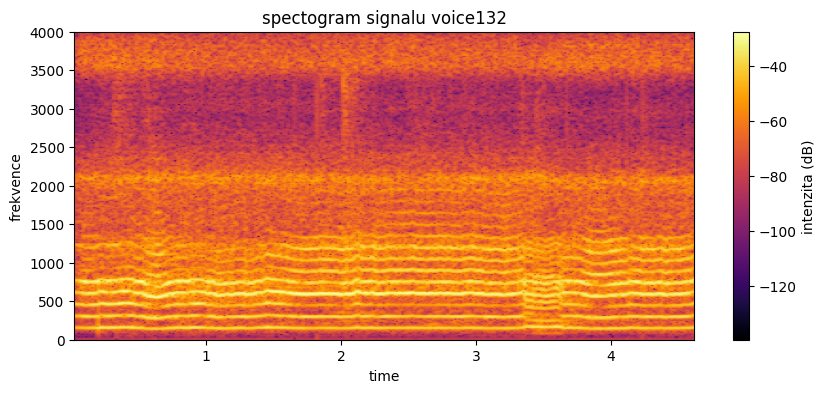

In [5]:
analyze(records[131], True)

In [8]:
df2

,diagnoza,healthy,anotace,cpp,instability,hlasitost,match
voice001,hyperkinetic dysphonia,0,hyperkinetic dysphonia,0.25,249.59,0.37,1
voice002,healthy,1,healthy,0.55,156.41,1.83,1
voice003,healthy,1,hyperkinetic dysphonia,0.42,21.28,1.46,0
voice004,hypokinetic dysphonia,0,hypokinetic dysphonia,0.32,4.76,0.06,1
voice005,healthy,1,hypokinetic dysphonia,0.46,13.95,0.75,0
...,...,...,...,...,...,...,...
voice204,healthy,1,healthy,0.40,307.52,0.47,1
voice205,hyperkinetic dysphonia,0,hyperkinetic dysphonia,0.23,173.80,1.15,1
voice206,healthy,1,healthy,0.48,64.44,2.37,1
voice207,reflux laryngitis,0,healthy,0.30,7.71,0.95,0


In [6]:
data = {}
data["moje vysledky"] = df2["match"].value_counts().values

sum = df2["match"].value_counts().sum()
matched = df2["match"].sum()
acc = round((matched / sum) * 100)

data["uspesnost"] = ["", f"{acc}%"]

pd.DataFrame.from_dict(data, orient="index", columns=["not matched", "matched"])



,not matched,matched
moje vysledky,135,73
uspesnost,,35%
